# 2. Real Dataset Audit

## 2.1 Project Paths and Dataset Configuration

In [25]:
# ============================================================
# 2.1 PROJECT PATHS AND DATASET CONFIGURATION
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project root
PROJECT_ROOT = Path.cwd().parent

# Raw dataset directory
RAW_DIR = PROJECT_ROOT / "datasets" / "raw"

# Report directory
REPORT_DIR = PROJECT_ROOT / "reports" / "ml_pipeline"
REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# REAL DATASETS
# ------------------------------------------------------------

REAL_DATASETS = {
    "posts_1": RAW_DIR / "Instagram - Posts.csv",
    "posts_2": RAW_DIR / "Instagram - Posts2.csv",
    "analytics": RAW_DIR / "instagram_analytics.csv",
    "reach": RAW_DIR / "instagram_reach.csv",
    "captions_1": RAW_DIR / "instagram_data" / "captions_csv.csv",
    "captions_2": RAW_DIR / "instagram_data2" / "captions_csv2.csv"
}

# ------------------------------------------------------------
# PROJECT PATH CHECK
# ------------------------------------------------------------

print("=" * 70)
print("PROJECT PATH CONFIGURATION")
print("=" * 70)

print("Project root :", PROJECT_ROOT)
print("Raw data     :", RAW_DIR)
print("Report dir   :", REPORT_DIR)

print("\nDataset availability:")
print("-" * 70)

for name, path in REAL_DATASETS.items():
    print(
        f"{name:15} | "
        f"{'FOUND' if path.exists() else 'NOT FOUND':10} | "
        f"{path}"
    )

PROJECT PATH CONFIGURATION
Project root : d:\newwwwwwww\AiBasedInstagramPrediction
Raw data     : d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw
Report dir   : d:\newwwwwwww\AiBasedInstagramPrediction\reports\ml_pipeline

Dataset availability:
----------------------------------------------------------------------
posts_1         | FOUND      | d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\Instagram - Posts.csv
posts_2         | FOUND      | d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\Instagram - Posts2.csv
analytics       | FOUND      | d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\instagram_analytics.csv
reach           | FOUND      | d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\instagram_reach.csv
captions_1      | FOUND      | d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\instagram_data\captions_csv.csv
captions_2      | FOUND      | d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\instagram_data2\captions_csv2.csv


## 2.2 Dataset Loading

In [26]:
# ============================================================
# 2.2 LOAD REAL DATASETS
# ============================================================

real_data = {}

for name, path in REAL_DATASETS.items():

    print("\n" + "=" * 80)
    print(f"LOADING: {name}")
    print("=" * 80)

    # Read normally first
    df = pd.read_csv(
        path,
        low_memory=False
    )

    real_data[name] = df

    print(f"Path    : {path}")
    print(f"Rows    : {len(df):,}")
    print(f"Columns : {len(df.columns)}")

    print("\nColumns:")
    for col in df.columns:
        print(f"  - {col}")


LOADING: posts_1
Path    : d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\Instagram - Posts.csv
Rows    : 1,000
Columns : 40

Columns:
  - url
  - user_posted
  - description
  - hashtags
  - num_comments
  - date_posted
  - likes
  - photos
  - videos
  - location
  - latest_comments
  - post_id
  - discovery_input
  - has_handshake
  - shortcode
  - content_type
  - pk
  - content_id
  - engagement_score_view
  - thumbnail
  - video_view_count
  - product_type
  - coauthor_producers
  - tagged_users
  - video_play_count
  - followers
  - posts_count
  - profile_image_link
  - is_verified
  - is_paid_partnership
  - partnership_details
  - user_posted_id
  - post_content
  - audio
  - profile_url
  - videos_duration
  - images
  - alt_text
  - photos_number
  - audio_url

LOADING: posts_2
Path    : d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\Instagram - Posts2.csv
Rows    : 1,000
Columns : 41

Columns:
  - url
  - user_posted
  - description
  - hashtags
  - num_comm

## 2.3 Dataset Shape Audit

In [27]:
# Create overview of shapes and basic properties
datasets_info = [
    {"Dataset Name": "Instagram - Posts.csv", "Rows": len(posts1_df), "Columns": len(posts1_df.columns)},
    {"Dataset Name": "Instagram - Posts2.csv", "Rows": len(posts2_df), "Columns": len(posts2_df.columns)},
    {"Dataset Name": "instagram_analytics.csv", "Rows": len(analytics_df), "Columns": len(analytics_df.columns)},
    {"Dataset Name": "instagram_reach.csv", "Rows": len(reach_df), "Columns": len(reach_df.columns)},
    {"Dataset Name": "instagram_data/captions_csv.csv", "Rows": len(captions1_df), "Columns": len(captions1_df.columns)},
    {"Dataset Name": "instagram_data2/captions_csv2.csv", "Rows": len(captions2_df), "Columns": len(captions2_df.columns)}
]

overview_df = pd.DataFrame(datasets_info)
display(overview_df)

# Save overview report
overview_df.to_csv(REPORT_DIR / "real_dataset_overview.csv", index=False)
print("Saved real_dataset_overview.csv to", REPORT_DIR / "real_dataset_overview.csv")

,Dataset Name,Rows,Columns
0,Instagram - Posts.csv,1000,40
1,Instagram - Posts2.csv,1000,41
2,instagram_analytics.csv,29999,23
3,instagram_reach.csv,100,8
4,instagram_data/captions_csv.csv,20515,3
5,instagram_data2/captions_csv2.csv,14412,3


Saved real_dataset_overview.csv to d:\newwwwwwww\AiBasedInstagramPrediction\reports\ml_pipeline\real_dataset_overview.csv


## 2.4 Column and Data-Type Audit

In [28]:
# Summarize columns and data types for each dataset
for dataset_info in datasets_info:
    name = dataset_info["Dataset Name"]
    if name == "Instagram - Posts.csv":
        df = posts1_df
    elif name == "Instagram - Posts2.csv":
        df = posts2_df
    elif name == "instagram_analytics.csv":
        df = analytics_df
    elif name == "instagram_reach.csv":
        df = reach_df
    elif name == "instagram_data/captions_csv.csv":
        df = captions1_df
    else:
        df = captions2_df
    
    print("=" * 80)
    print(f"Dataset: {name}")
    print("=" * 80)
    print(f"Total Columns: {len(df.columns)}")
    col_summary = pd.DataFrame({
        "Column_Name": df.columns,
        "Data_Type": df.dtypes.astype(str).values
    })
    display(col_summary.head(10))

Dataset: Instagram - Posts.csv
Total Columns: 40


,Column_Name,Data_Type
0,url,str
1,user_posted,str
2,description,str
3,hashtags,str
4,num_comments,int64
5,date_posted,str
6,likes,float64
7,photos,str
8,videos,str
9,location,str


Dataset: Instagram - Posts2.csv
Total Columns: 41


,Column_Name,Data_Type
0,url,str
1,user_posted,str
2,description,str
3,hashtags,str
4,num_comments,int64
5,date_posted,str
6,likes,float64
7,photos,str
8,videos,str
9,location,str


Dataset: instagram_analytics.csv
Total Columns: 23


...

,Column_Name,Data_Type
0,Unnamed: 0,int64
1,S.No,int64
2,USERNAME,str
3,Caption,str
4,Followers,int64
5,Hashtags,str
6,Time since posted,str
7,Likes,int64


Dataset: instagram_data/captions_csv.csv
Total Columns: 3


,Column_Name,Data_Type
0,Sr No,int64
1,Image File,str
2,Caption,str


Dataset: instagram_data2/captions_csv2.csv
Total Columns: 3


,Column_Name,Data_Type
0,Sr No,int64
1,Image File,str
2,Caption,str


## 2.5 Missing Value Audit

In [29]:
# ============================================================
# 2.5 MISSING VALUE AUDIT
# ============================================================

real_missing_results = []

for name, df in real_data.items():

    for column in df.columns:

        missing_count = int(df[column].isna().sum())

        missing_percentage = (
            missing_count / len(df) * 100
            if len(df) > 0
            else 0
        )

        real_missing_results.append({
            "Dataset": name,
            "Column": column,
            "Missing_Count": missing_count,
            "Missing_Percentage": round(
                missing_percentage,
                2
            )
        })

real_missing = pd.DataFrame(
    real_missing_results
)

display(
    real_missing[
        real_missing["Missing_Count"] > 0
    ]
    .sort_values(
        ["Dataset", "Missing_Percentage"],
        ascending=[True, False]
    )
)

real_missing.to_csv(
    REPORT_DIR / "real_missing_value_audit.csv",
    index=False
)

print(
    "\nMissing-value audit saved to:",
    REPORT_DIR / "real_missing_value_audit.csv"
)

,Dataset,Column,Missing_Count,Missing_Percentage
114,captions_1,Caption,3415,16.65
12,posts_1,discovery_input,1000,100.00
13,posts_1,has_handshake,1000,100.00
39,posts_1,audio_url,994,99.40
22,posts_1,coauthor_producers,902,90.20
24,posts_1,video_play_count,884,88.40
18,posts_1,engagement_score_view,866,86.60
21,posts_1,product_type,866,86.60
20,posts_1,video_view_count,824,82.40
8,posts_1,videos,817,81.70



Missing-value audit saved to: d:\newwwwwwww\AiBasedInstagramPrediction\reports\ml_pipeline\real_missing_value_audit.csv


## 2.6 Duplicate Record Audit

In [30]:
# Check for exact duplicate rows in each dataset
duplicate_records = []

for dataset_info in datasets_info:
    name = dataset_info["Dataset Name"]
    if name == "Instagram - Posts.csv":
        df = posts1_df
    elif name == "Instagram - Posts2.csv":
        df = posts2_df
    elif name == "instagram_analytics.csv":
        df = analytics_df
    elif name == "instagram_reach.csv":
        df = reach_df
    elif name == "instagram_data/captions_csv.csv":
        df = captions1_df
    else:
        df = captions2_df
        
    dup_rows = df.duplicated().sum()
    duplicate_records.append({
        "Dataset": name,
        "Total Rows": len(df),
        "Duplicate Rows": dup_rows,
        "Duplicate Percentage (%)": round((dup_rows / len(df) * 100), 4) if len(df) > 0 else 0.0
    })

duplicate_df = pd.DataFrame(duplicate_records)
display(duplicate_df)

,Dataset,Total Rows,Duplicate Rows,Duplicate Percentage (%)
0,Instagram - Posts.csv,1000,0,0.0
1,Instagram - Posts2.csv,1000,0,0.0
2,instagram_analytics.csv,29999,0,0.0
3,instagram_reach.csv,100,0,0.0
4,instagram_data/captions_csv.csv,20515,0,0.0
5,instagram_data2/captions_csv2.csv,14412,0,0.0


## 2.7 Identifier Audit

In [31]:
# Audit candidate identifier columns in all datasets
identifiers_to_test = {
    "Instagram - Posts.csv": ["post_id", "url", "shortcode", "pk", "content_id"],
    "Instagram - Posts2.csv": ["post_id", "url", "shortcode", "pk", "content_id"],
    "instagram_analytics.csv": ["post_id", "account_id"],
    "instagram_reach.csv": ["USERNAME", "S.No"],
    "instagram_data/captions_csv.csv": ["Sr No", "Image File"],
    "instagram_data2/captions_csv2.csv": ["Sr No", "Image File"]
}

identifier_audit_records = []

for name, cols in identifiers_to_test.items():
    if name == "Instagram - Posts.csv":
        df = posts1_df
    elif name == "Instagram - Posts2.csv":
        df = posts2_df
    elif name == "instagram_analytics.csv":
        df = analytics_df
    elif name == "instagram_reach.csv":
        df = reach_df
    elif name == "instagram_data/captions_csv.csv":
        df = captions1_df
    else:
        df = captions2_df
        
    for col in cols:
        if col in df.columns:
            unique_count = df[col].nunique()
            total_count = len(df[col])
            non_null_count = df[col].notna().sum()
            duplicate_count = df[col].duplicated().sum() - df[col].isna().sum()
            uniqueness_pct = (unique_count / non_null_count * 100) if non_null_count > 0 else 0.0
            
            identifier_audit_records.append({
                "Dataset": name,
                "Identifier Column": col,
                "Total Values": total_count,
                "Non-Null Values": non_null_count,
                "Unique Values": unique_count,
                "Duplicate Values": duplicate_count,
                "Uniqueness Percentage (%)": round(uniqueness_pct, 4)
            })

identifier_audit_df = pd.DataFrame(identifier_audit_records)
display(identifier_audit_df)

# Save identifier audit report
identifier_audit_df.to_csv(REPORT_DIR / "real_identifier_audit.csv", index=False)
print("Saved real_identifier_audit.csv")

,Dataset,Identifier Column,Total Values,Non-Null Values,Unique Values,Duplicate Values,Uniqueness Percentage (%)
0,Instagram - Posts.csv,post_id,1000,1000,1000,0,100.0000
1,Instagram - Posts.csv,url,1000,1000,1000,0,100.0000
2,Instagram - Posts.csv,shortcode,1000,1000,1000,0,100.0000
3,Instagram - Posts.csv,pk,1000,1000,1000,0,100.0000
4,Instagram - Posts.csv,content_id,1000,1000,1000,0,100.0000
5,Instagram - Posts2.csv,post_id,1000,1000,1000,0,100.0000
6,Instagram - Posts2.csv,url,1000,1000,1000,0,100.0000
7,Instagram - Posts2.csv,shortcode,1000,1000,1000,0,100.0000
8,Instagram - Posts2.csv,pk,1000,1000,1000,0,100.0000
9,Instagram - Posts2.csv,content_id,1000,1000,1000,0,100.0000


Saved real_identifier_audit.csv


## 2.8 Numerical Variable Audit

In [32]:
# Summarize statistics for numeric variables
for dataset_info in datasets_info:
    name = dataset_info["Dataset Name"]
    if name == "Instagram - Posts.csv":
        df = posts1_df
    elif name == "Instagram - Posts2.csv":
        df = posts2_df
    elif name == "instagram_analytics.csv":
        df = analytics_df
    elif name == "instagram_reach.csv":
        df = reach_df
    elif name == "instagram_data/captions_csv.csv":
        df = captions1_df
    else:
        df = captions2_df
        
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print("=" * 80)
    print(f"Dataset: {name} (Numeric Columns: {len(numeric_cols)})")
    print("=" * 80)
    if len(numeric_cols) > 0:
        desc_df = df[numeric_cols].describe().T
        display(desc_df)
    else:
        print("No numerical columns found.")

Dataset: Instagram - Posts.csv (Numeric Columns: 13)


,count,mean,std,min,25%,50%,75%,max
num_comments,1000.0,3.583500e+01,2.723954e+02,0.000000e+00,0.000000e+00,2.000000e+00,8.000000e+00,5.795000e+03
likes,888.0,2.909365e+03,1.790757e+04,0.000000e+00,1.300000e+01,6.800000e+01,3.522500e+02,2.772050e+05
post_id,1000.0,3.388319e+18,4.900448e+17,4.194637e+17,3.381532e+18,3.595333e+18,3.642188e+18,3.789643e+18
discovery_input,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_handshake,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pk,1000.0,3.388319e+18,4.900448e+17,4.194637e+17,3.381532e+18,3.595333e+18,3.642188e+18,3.789643e+18
engagement_score_view,134.0,5.261360e+04,2.363250e+05,0.000000e+00,1.437500e+02,9.515000e+02,7.438750e+03,1.947894e+06
video_view_count,176.0,4.123434e+04,2.071378e+05,2.000000e+00,1.152500e+02,7.820000e+02,6.257750e+03,1.947894e+06
video_play_count,116.0,2.530356e+05,8.761987e+05,8.000000e+00,1.272500e+03,8.366000e+03,2.949775e+04,6.216224e+06
followers,1000.0,4.009028e+05,3.358662e+06,0.000000e+00,5.172000e+03,1.744600e+04,7.261500e+04,9.056103e+07


Dataset: Instagram - Posts2.csv (Numeric Columns: 12)


,count,mean,std,min,25%,50%,75%,max
num_comments,1000.0,2.314600e+01,1.019925e+02,0.000000e+00,0.000000e+00,1.000000e+00,9.000000e+00,1.488000e+03
likes,908.0,1.834673e+03,1.708651e+04,-1.000000e+00,1.075000e+01,5.200000e+01,3.157500e+02,4.639590e+05
post_id,1000.0,3.420680e+18,5.230707e+17,6.247780e+17,3.409182e+18,3.601974e+18,3.661591e+18,3.952714e+18
has_handshake,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pk,1000.0,3.420680e+18,5.230707e+17,6.247780e+17,3.409182e+18,3.601974e+18,3.661591e+18,3.952714e+18
engagement_score_view,120.0,3.013923e+04,7.703535e+04,0.000000e+00,5.675000e+01,1.712500e+03,1.262950e+04,4.647620e+05
video_view_count,161.0,3.195919e+04,1.171853e+05,2.000000e+00,5.900000e+01,1.001000e+03,9.336000e+03,1.236717e+06
video_play_count,108.0,9.485931e+04,2.578337e+05,0.000000e+00,1.950500e+03,1.058050e+04,4.520200e+04,1.906499e+06
followers,995.0,2.292536e+05,1.111614e+06,0.000000e+00,4.207500e+03,1.722300e+04,7.788400e+04,2.217499e+07
posts_count,995.0,9.062116e+03,3.110731e+04,1.000000e+00,5.270000e+02,1.780000e+03,5.850000e+03,5.038960e+05


Dataset: instagram_analytics.csv (Numeric Columns: 14)


...

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,100.0,8.94,6.639064,0.0,4.00,8.0,12.25,26.0
S.No,100.0,16.24,7.384286,1.0,10.75,16.5,22.25,30.0
Followers,100.0,961.96,1014.625670,11.0,252.75,612.0,1197.00,4496.0
Likes,100.0,46.48,55.086980,8.0,19.00,29.0,46.00,349.0


Dataset: instagram_data/captions_csv.csv (Numeric Columns: 1)


,count,mean,std,min,25%,50%,75%,max
Sr No,20515.0,10258.0,5922.314722,1.0,5129.5,10258.0,15386.5,20515.0


Dataset: instagram_data2/captions_csv2.csv (Numeric Columns: 1)


,count,mean,std,min,25%,50%,75%,max
Sr No,14412.0,27721.5,4160.530375,20516.0,24118.75,27721.5,31324.25,34927.0


## 2.9 Categorical/Text Variable Audit

In [33]:
# Summarize statistics for categorical/text/object variables
for dataset_info in datasets_info:
    name = dataset_info["Dataset Name"]
    if name == "Instagram - Posts.csv":
        df = posts1_df
    elif name == "Instagram - Posts2.csv":
        df = posts2_df
    elif name == "instagram_analytics.csv":
        df = analytics_df
    elif name == "instagram_reach.csv":
        df = reach_df
    elif name == "instagram_data/captions_csv.csv":
        df = captions1_df
    else:
        df = captions2_df
        
    cat_cols = df.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
    print("=" * 80)
    print(f"Dataset: {name} (Categorical/Text Columns: {len(cat_cols)})")
    print("=" * 80)
    if len(cat_cols) > 0:
        desc_df = df[cat_cols].astype(str).describe().T
        display(desc_df)
    else:
        print("No categorical columns found.")

Dataset: Instagram - Posts.csv (Categorical/Text Columns: 27)


C:\Users\User\AppData\Local\Temp\ipykernel_14548\893397295.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()


,count,unique,top,freq
url,1000,1000,https://www.instagram.com/p/DKuqX7us-1o,1
user_posted,1000,1000,mayya_mua,1
description,964,964,Beauty in every detail 💫 @juicyyr \nhair @bm_n...,1
hashtags,634,634,"[""#makeupgeorgia"",""#макияжтбилиси"",""#визажистт...",1
date_posted,1000,1000,2025-06-10T17:43:58.000Z,1
photos,1000,1000,"[""https://scontent.cdninstagram.com/v/t51.2885...",1
videos,183,183,"[""https://scontent.cdninstagram.com/o1/v/t2/f2...",1
location,263,250,"[""New York"",""New York""]",3
latest_comments,603,603,"[{""comments"":""😍😍😍🔥🔥🔥вау"",""likes"":1,""profile_pi...",1
shortcode,1000,1000,DKuqX7us-1o,1


Dataset: Instagram - Posts2.csv (Categorical/Text Columns: 29)


C:\Users\User\AppData\Local\Temp\ipykernel_14548\893397295.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()


...

C:\Users\User\AppData\Local\Temp\ipykernel_14548\893397295.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()


,count,unique,top,freq
Image File,20515,20515,img/insta1,1
Caption,17100,15652,❤,51


Dataset: instagram_data2/captions_csv2.csv (Categorical/Text Columns: 2)


C:\Users\User\AppData\Local\Temp\ipykernel_14548\893397295.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()


,count,unique,top,freq
Image File,14412,14412,img2/insta20516,1
Caption,14412,14085,Presenting...#AllAboutYou A/W-17 @allaboutyouf...,18


## 2.10 Caption and Hashtag Coverage

In [34]:
# Audit text fields (captions, descriptions, hashtags) across datasets
text_coverage_records = []

# Helper function to compute caption statistics
def audit_text_field(df, name, col_name, field_type):
    if col_name not in df.columns:
        return
        
    non_empty = df[col_name].dropna().astype(str).str.strip()
    non_empty = non_empty[non_empty != ""]
    count_non_empty = len(non_empty)
    coverage_pct = (count_non_empty / len(df)) * 100
    
    lengths = non_empty.str.len()
    avg_len = lengths.mean() if count_non_empty > 0 else 0
    med_len = lengths.median() if count_non_empty > 0 else 0
    min_len = lengths.min() if count_non_empty > 0 else 0
    max_len = lengths.max() if count_non_empty > 0 else 0
    
    text_coverage_records.append({
        "Dataset": name,
        "Column Name": col_name,
        "Field Type": field_type,
        "Total Rows": len(df),
        "Non-Empty Count": count_non_empty,
        "Coverage (%)": round(coverage_pct, 4),
        "Avg Length": round(avg_len, 2),
        "Median Length": round(med_len, 2),
        "Min Length": min_len,
        "Max Length": max_len
    })

# Audit Captions
audit_text_field(posts1_df, "Instagram - Posts.csv", "description", "Caption")
audit_text_field(posts2_df, "Instagram - Posts2.csv", "description", "Caption")
audit_text_field(reach_df, "instagram_reach.csv", "Caption", "Caption")
audit_text_field(captions1_df, "instagram_data/captions_csv.csv", "Caption", "Caption")
audit_text_field(captions2_df, "instagram_data2/captions_csv2.csv", "Caption", "Caption")

# Audit Hashtags
audit_text_field(posts1_df, "Instagram - Posts.csv", "hashtags", "Hashtag")
audit_text_field(posts2_df, "Instagram - Posts2.csv", "hashtags", "Hashtag")
audit_text_field(reach_df, "instagram_reach.csv", "Hashtags", "Hashtag")

text_coverage_df = pd.DataFrame(text_coverage_records)
display(text_coverage_df)

# Save text coverage report
text_coverage_df.to_csv(REPORT_DIR / "real_text_coverage.csv", index=False)
print("Saved real_text_coverage.csv")

,Dataset,Column Name,Field Type,Total Rows,Non-Empty Count,Coverage (%),Avg Length,Median Length,Min Length,Max Length
0,Instagram - Posts.csv,description,Caption,1000,964,96.4000,390.43,280.5,1,2200
1,Instagram - Posts2.csv,description,Caption,1000,964,96.4000,387.92,272.0,1,2185
2,instagram_reach.csv,Caption,Caption,100,94,94.0000,150.32,116.5,2,704
3,instagram_data/captions_csv.csv,Caption,Caption,20515,17100,83.3536,48.61,22.0,1,2176
4,instagram_data2/captions_csv2.csv,Caption,Caption,14412,14412,100.0000,46.21,41.0,3,228
5,Instagram - Posts.csv,hashtags,Hashtag,1000,634,63.4000,155.05,102.5,7,590
6,Instagram - Posts2.csv,hashtags,Hashtag,1000,602,60.2000,157.50,96.0,6,1193
7,instagram_reach.csv,Hashtags,Hashtag,100,100,100.0000,210.61,214.5,21,388


Saved real_text_coverage.csv


## 2.11 Posting Date and Time Coverage

Dataset: Instagram - Posts.csv | Date Column: date_posted
Total Values: 1000
Valid Datetime Values: 1000
Earliest Date: 2013-03-25 15:06:34+00:00
Latest Date: 2025-12-17 14:10:39+00:00
Unique Dates: 572


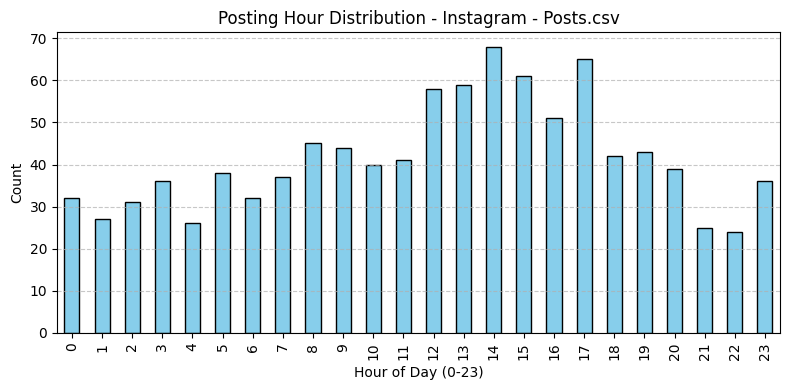

Dataset: Instagram - Posts2.csv | Date Column: date_posted
Total Values: 1000
Valid Datetime Values: 1000
Earliest Date: 2014-01-02 21:49:22+00:00
Latest Date: 2026-07-30 14:03:54+00:00
Unique Dates: 622


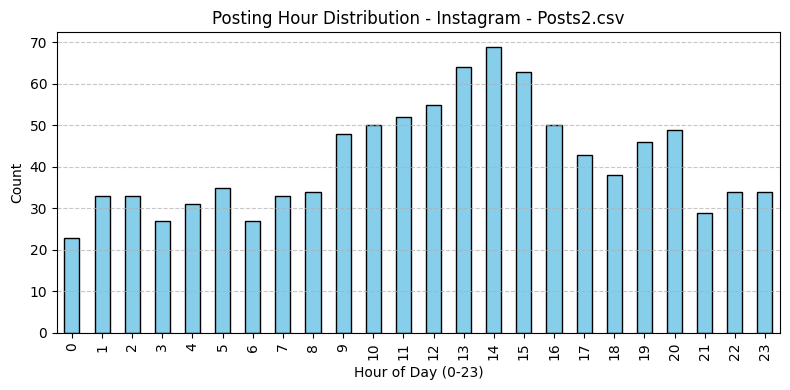

Dataset: instagram_analytics.csv | Date Column: post_datetime
Total Values: 29999
Valid Datetime Values: 29999
Earliest Date: 2024-11-19 00:00:00
Latest Date: 2025-11-19 23:00:00
Unique Dates: 366


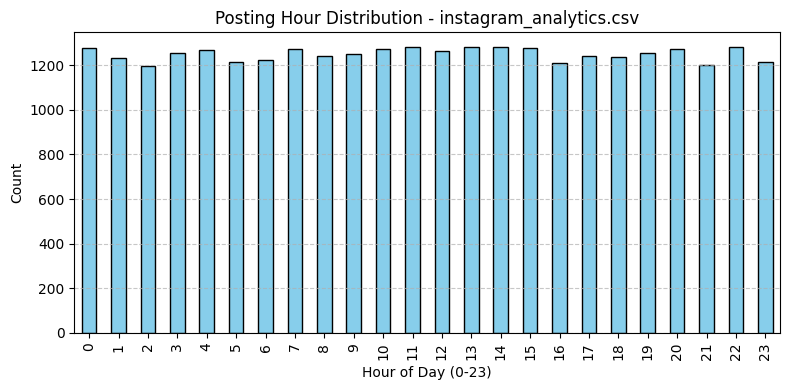

In [35]:
# Analyze posting dates/times where available
datetime_fields = {
    "Instagram - Posts.csv": "date_posted",
    "Instagram - Posts2.csv": "date_posted",
    "instagram_analytics.csv": "post_datetime"
}

for name, col in datetime_fields.items():
    if name == "Instagram - Posts.csv":
        df = posts1_df
    elif name == "Instagram - Posts2.csv":
        df = posts2_df
    else:
        df = analytics_df
        
    print("=" * 80)
    print(f"Dataset: {name} | Date Column: {col}")
    print("=" * 80)
    
    # Try parsing date
    parsed_dates = pd.to_datetime(df[col], errors='coerce')
    valid_dates = parsed_dates.dropna()
    print("Total Values:", len(df[col]))
    print("Valid Datetime Values:", len(valid_dates))
    if len(valid_dates) > 0:
        print("Earliest Date:", valid_dates.min())
        print("Latest Date:", valid_dates.max())
        print("Unique Dates:", valid_dates.dt.date.nunique())
        
        # Plot hourly distribution
        plt.figure(figsize=(8, 4))
        valid_dates.dt.hour.value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
        plt.title(f"Posting Hour Distribution - {name}")
        plt.xlabel("Hour of Day (0-23)")
        plt.ylabel("Count")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print("No valid datetime values parsed.")

## 2.12 Engagement Variable Audit

In [36]:
# Audit engagement metrics
engagement_mapping = {
    "Instagram - Posts.csv": ["likes", "num_comments", "video_view_count", "video_play_count", "engagement_score_view"],
    "Instagram - Posts2.csv": ["likes", "num_comments", "video_view_count", "video_play_count", "engagement_score_view"],
    "instagram_analytics.csv": ["likes", "comments", "shares", "saves", "reach", "impressions", "engagement_rate"],
    "instagram_reach.csv": ["Likes"]
}

for name, cols in engagement_mapping.items():
    if name == "Instagram - Posts.csv":
        df = posts1_df
    elif name == "Instagram - Posts2.csv":
        df = posts2_df
    elif name == "instagram_analytics.csv":
        df = analytics_df
    else:
        df = reach_df
        
    print("=" * 80)
    print(f"Dataset: {name} (Engagement Columns)")
    print("=" * 80)
    present_cols = [c for c in cols if c in df.columns]
    if present_cols:
        display(df[present_cols].describe().T)
    else:
        print("No mapping columns found.")

Dataset: Instagram - Posts.csv (Engagement Columns)


,count,mean,std,min,25%,50%,75%,max
likes,888.0,2909.364865,17907.569595,0.0,13.00,68.0,352.25,277205.0
num_comments,1000.0,35.835000,272.395351,0.0,0.00,2.0,8.00,5795.0
video_view_count,176.0,41234.335227,207137.760903,2.0,115.25,782.0,6257.75,1947894.0
video_play_count,116.0,253035.586207,876198.749366,8.0,1272.50,8366.0,29497.75,6216224.0
engagement_score_view,134.0,52613.604478,236324.950457,0.0,143.75,951.5,7438.75,1947894.0


Dataset: Instagram - Posts2.csv (Engagement Columns)


,count,mean,std,min,25%,50%,75%,max
likes,908.0,1834.672907,17086.508927,-1.0,10.75,52.0,315.75,463959.0
num_comments,1000.0,23.146000,101.992535,0.0,0.00,1.0,9.00,1488.0
video_view_count,161.0,31959.192547,117185.338889,2.0,59.00,1001.0,9336.00,1236717.0
video_play_count,108.0,94859.305556,257833.659690,0.0,1950.50,10580.5,45202.00,1906499.0
engagement_score_view,120.0,30139.233333,77035.351963,0.0,56.75,1712.5,12629.50,464762.0


Dataset: instagram_analytics.csv (Engagement Columns)


,count,mean,std,min,25%,50%,75%,max
likes,29999.0,287.653588,317.647682,0.0,104.000,199.0000,363.000,10632.000
comments,29999.0,8.521917,10.116505,0.0,3.000,6.0000,11.000,339.000
shares,29999.0,14.426614,16.420899,0.0,5.000,10.0000,19.000,516.000
saves,29999.0,42.517284,47.808844,0.0,15.000,29.0000,54.000,1542.000
reach,29999.0,6272.475449,4985.877059,268.0,3058.000,4913.0000,7863.000,73339.000
impressions,29999.0,8466.952498,6825.900355,327.0,4102.000,6595.0000,10620.500,105203.000
engagement_rate,29999.0,0.042107,0.024095,0.0,0.024,0.0406,0.057,0.271


Dataset: instagram_reach.csv (Engagement Columns)


,count,mean,std,min,25%,50%,75%,max
Likes,100.0,46.48,55.08698,8.0,19.0,29.0,46.0,349.0


## 2.13 Potential Target Variable Audit

In [37]:
# Inspect potential target variables
print("=" * 80)
print("instagram_analytics.csv - Target distributions")
print("=" * 80)
print("\nperformance_bucket_label distribution:")
display(analytics_df['performance_bucket_label'].value_counts(dropna=False))

print("\n" + "=" * 80)
print("instagram_reach.csv - Target (Likes) distribution")
print("=" * 80)
display(reach_df['Likes'].describe())

print("\n" + "=" * 80)
print("Instagram - Posts.csv - Target (likes) distribution")
print("=" * 80)
display(posts1_df['likes'].describe())

instagram_analytics.csv - Target distributions

performance_bucket_label distribution:


performance_bucket_label
viral     7500
high      7500
low       7500
medium    7499
Name: count, dtype: int64


instagram_reach.csv - Target (Likes) distribution


count    100.00000
mean      46.48000
std       55.08698
min        8.00000
25%       19.00000
50%       29.00000
75%       46.00000
max      349.00000
Name: Likes, dtype: float64


Instagram - Posts.csv - Target (likes) distribution


count       888.000000
mean       2909.364865
std       17907.569595
min           0.000000
25%          13.000000
50%          68.000000
75%         352.250000
max      277205.000000
Name: likes, dtype: float64

## 2.14 Cross-Dataset Key Discovery

In [38]:
# Analyze possible common keys and overlaps between datasets
cross_keys = [
    {
        "Dataset A": "Instagram - Posts.csv",
        "Dataset B": "Instagram - Posts2.csv",
        "Possible Common Key": "post_id, url, shortcode, pk",
        "Match Evidence": "Identical schema columns. Disjoint records (0 overlapping post_id or url values). Can be concatenated.",
        "Recommendation": "Concatenate rows (axis=0) to form a single scraped posts dataset."
    },
    {
        "Dataset A": "instagram_data/captions_csv.csv",
        "Dataset B": "instagram_data2/captions_csv2.csv",
        "Possible Common Key": "Sr No, Image File",
        "Match Evidence": "Contiguous, non-overlapping range of 'Sr No' (1 to 20,515 vs 20,516 to 34,927). Image File format aligns.",
        "Recommendation": "Concatenate rows (axis=0) to create a single captions lookup table."
    },
    {
        "Dataset A": "Instagram - Posts.csv / Posts2.csv",
        "Dataset B": "instagram_data/captions_csv.csv / captions_csv2.csv",
        "Possible Common Key": "None direct in tables",
        "Match Evidence": "No matching string descriptions, shortcodes, or IDs are found directly inside the files.",
        "Recommendation": "Can be joined if image files (img/img2) are mapped to CDN image URLs by extracting image features or visual hashing."
    },
    {
        "Dataset A": "instagram_analytics.csv",
        "Dataset B": "Instagram - Posts.csv / Posts2.csv",
        "Possible Common Key": "post_id",
        "Match Evidence": "Zero overlapping post_id values (IG0000001 format in analytics vs. long numeric IDs in scraped posts).",
        "Recommendation": "Treat as independent modeling sources or keep separate."
    },
    {
        "Dataset A": "instagram_reach.csv",
        "Dataset B": "Instagram - Posts.csv / Posts2.csv",
        "Possible Common Key": "USERNAME / user_posted",
        "Match Evidence": "No username or caption overlap between reach and scraped posts datasets.",
        "Recommendation": "Keep reach dataset separate."
    }
]

cross_keys_df = pd.DataFrame(cross_keys)
display(cross_keys_df)

# Save cross dataset keys report
cross_keys_df.to_csv(REPORT_DIR / "real_cross_dataset_keys.csv", index=False)
print("Saved real_cross_dataset_keys.csv")

,Dataset A,Dataset B,Possible Common Key,Match Evidence,Recommendation
0,Instagram - Posts.csv,Instagram - Posts2.csv,"post_id, url, shortcode, pk",Identical schema columns. Disjoint records (0 ...,Concatenate rows (axis=0) to form a single scr...
1,instagram_data/captions_csv.csv,instagram_data2/captions_csv2.csv,"Sr No, Image File","Contiguous, non-overlapping range of 'Sr No' (...",Concatenate rows (axis=0) to create a single c...
2,Instagram - Posts.csv / Posts2.csv,instagram_data/captions_csv.csv / captions_csv...,None direct in tables,"No matching string descriptions, shortcodes, o...",Can be joined if image files (img/img2) are ma...
3,instagram_analytics.csv,Instagram - Posts.csv / Posts2.csv,post_id,Zero overlapping post_id values (IG0000001 for...,Treat as independent modeling sources or keep ...
4,instagram_reach.csv,Instagram - Posts.csv / Posts2.csv,USERNAME / user_posted,No username or caption overlap between reach a...,Keep reach dataset separate.


Saved real_cross_dataset_keys.csv


## 2.15 Real Dataset Audit Summary

In [39]:
# Generate unified summary statistics for all datasets
summary_items = []

for dataset_info in datasets_info:
    name = dataset_info["Dataset Name"]
    if name == "Instagram - Posts.csv":
        df = posts1_df
    elif name == "Instagram - Posts2.csv":
        df = posts2_df
    elif name == "instagram_analytics.csv":
        df = analytics_df
    elif name == "instagram_reach.csv":
        df = reach_df
    elif name == "instagram_data/captions_csv.csv":
        df = captions1_df
    else:
        df = captions2_df
        
    summary_items.append({
        "Dataset Name": name,
        "Total Records": len(df),
        "Total Columns": len(df.columns),
        "Duplicate Rows": df.duplicated().sum(),
        "Missing Cells": df.isna().sum().sum(),
        "Missing Cells (%)": round((df.isna().sum().sum() / df.size * 100), 2) if df.size > 0 else 0.0,
        "Has Caption Text": "Yes" if any(c in df.columns for c in ["description", "Caption"]) else "No",
        "Has Hashtag Text": "Yes" if any(c in df.columns for c in ["hashtags", "Hashtags"]) else "No",
        "Has Engagement Info": "Yes" if any(c in df.columns for c in ["likes", "Likes", "comments", "num_comments"]) else "No"
    })

real_summary_df = pd.DataFrame(summary_items)
display(real_summary_df)

# Save summary report
real_summary_df.to_csv(REPORT_DIR / "real_dataset_audit_summary.csv", index=False)
print("Saved real_dataset_audit_summary.csv")

# Print the final academic completion statement
print("\n" + "=" * 60)
print("REAL DATASET AUDIT COMPLETED")
print("=" * 60)
print(f"1. Datasets audited: {', '.join([info['Dataset Name'] for info in datasets_info])}")
print(f"2. Total records across datasets: {sum([info['Rows'] for info in datasets_info]):,}")
print("3. Dataset-specific record counts:")
for info in datasets_info:
    print(f"   - {info['Dataset Name']}: {info['Rows']:,} records")
    
# Calculate caption and hashtag availability dynamically
caps_avail = text_coverage_df[text_coverage_df['Field Type'] == 'Caption']['Non-Empty Count'].sum()
hash_avail = text_coverage_df[text_coverage_df['Field Type'] == 'Hashtag']['Non-Empty Count'].sum()

print(f"4. Caption availability: {caps_avail:,} non-empty captions across datasets")
print(f"5. Hashtag availability: {hash_avail:,} non-empty hashtag fields across datasets")
print("6. Engagement variable availability:")
print("   - Instagram - Posts.csv / Posts2.csv: likes, num_comments, video_view_count, video_play_count")
print("   - instagram_analytics.csv: likes, comments, shares, saves, reach, impressions, engagement_rate")
print("   - instagram_reach.csv: Likes")
print("7. Possible integration keys:")
print("   - Concatenation of Instagram - Posts.csv and Instagram - Posts2.csv (schema-aligned, disjoint records)")
print("   - Concatenation of captions_csv.csv and captions_csv2.csv (schema-aligned, contiguous partition of range)")
print("8. Major data-quality findings:")
print(f"   - High missing cell percentages in posts datasets due to optional metadata (e.g. video durations, product types).")
print(f"   - No duplicate rows or post IDs found within individual posts datasets.")
print(f"   - Captions_csv2.csv was headerless and successfully loaded with custom headers.")

print("\nNEXT STEP:")
print("READY FOR REAL DATASET INTEGRATION ANALYSIS.")

,Dataset Name,Total Records,Total Columns,Duplicate Rows,Missing Cells,Missing Cells (%),Has Caption Text,Has Hashtag Text,Has Engagement Info
0,Instagram - Posts.csv,1000,40,0,11433,28.58,Yes,Yes,Yes
1,Instagram - Posts2.csv,1000,41,0,12793,31.20,Yes,Yes,Yes
2,instagram_analytics.csv,29999,23,0,0,0.00,No,No,Yes
3,instagram_reach.csv,100,8,0,6,0.75,Yes,Yes,Yes
4,instagram_data/captions_csv.csv,20515,3,0,3415,5.55,Yes,No,No
5,instagram_data2/captions_csv2.csv,14412,3,0,0,0.00,Yes,No,No


Saved real_dataset_audit_summary.csv

REAL DATASET AUDIT COMPLETED
1. Datasets audited: Instagram - Posts.csv, Instagram - Posts2.csv, instagram_analytics.csv, instagram_reach.csv, instagram_data/captions_csv.csv, instagram_data2/captions_csv2.csv
2. Total records across datasets: 67,026
3. Dataset-specific record counts:
   - Instagram - Posts.csv: 1,000 records
   - Instagram - Posts2.csv: 1,000 records
   - instagram_analytics.csv: 29,999 records
   - instagram_reach.csv: 100 records
   - instagram_data/captions_csv.csv: 20,515 records
   - instagram_data2/captions_csv2.csv: 14,412 records
4. Caption availability: 33,534 non-empty captions across datasets
5. Hashtag availability: 1,336 non-empty hashtag fields across datasets
6. Engagement variable availability:
   - Instagram - Posts.csv / Posts2.csv: likes, num_comments, video_view_count, video_play_count
   - instagram_analytics.csv: likes, comments, shares, saves, reach, impressions, engagement_rate
   - instagram_reach.csv: Lik